In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:/Projects/loan_approval_dataset.csv")

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


In [62]:
df.shape

(4269, 13)

In [63]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')

In [64]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df.columns.tolist()

['loan_id',
 ' no_of_dependents',
 ' education',
 ' self_employed',
 ' income_annum',
 ' loan_amount',
 ' loan_term',
 ' cibil_score',
 ' residential_assets_value',
 ' commercial_assets_value',
 ' luxury_assets_value',
 ' bank_asset_value',
 ' loan_status']

In [67]:
df.columns = df.columns.str.strip()

In [68]:
df.columns.tolist()


['loan_id',
 'no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value',
 'loan_status']

In [69]:
df["loan_status"].unique()

<StringArray>
[' Approved', ' Rejected']
Length: 2, dtype: str

In [70]:
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    df[col] = df[col].str.strip()

C:\Users\User\AppData\Local\Temp\ipykernel_7524\1838545402.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include="object").columns


In [71]:
df["loan_status"].unique()

<StringArray>
['Approved', 'Rejected']
Length: 2, dtype: str

In [72]:
df.columns = df.columns.str.strip()

In [73]:
df.columns = df.columns.str.strip()

object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    df[col] = df[col].str.strip()

C:\Users\User\AppData\Local\Temp\ipykernel_7524\602484770.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include="object").columns


In [74]:
df["loan_status"].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

EDA

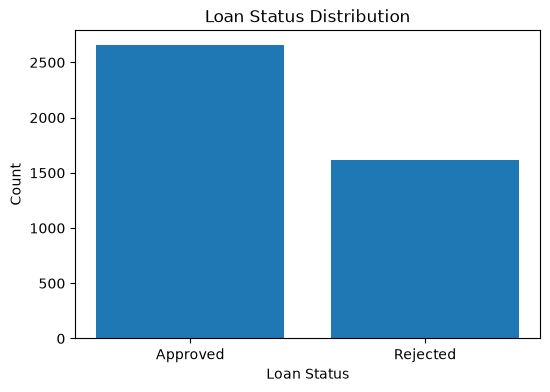

In [75]:
import matplotlib.pyplot as plt

loan_counts = df["loan_status"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(loan_counts.index, loan_counts.values)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

In [76]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Categorical Columns: ['education', 'self_employed', 'loan_status']


C:\Users\User\AppData\Local\Temp\ipykernel_7524\2336767767.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [77]:
df.columns.tolist()

['loan_id',
 'no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value',
 'loan_status']

In [78]:
df = df.drop("loan_id", axis=1)

In [79]:
df.columns.tolist()

['no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value',
 'loan_status']

In [80]:
print(df.columns.tolist())

['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [81]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Categorical Columns: ['education', 'self_employed', 'loan_status']


C:\Users\User\AppData\Local\Temp\ipykernel_7524\2336767767.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [82]:
categorical_cols = df.select_dtypes(
    exclude=["number"]
).columns.tolist()

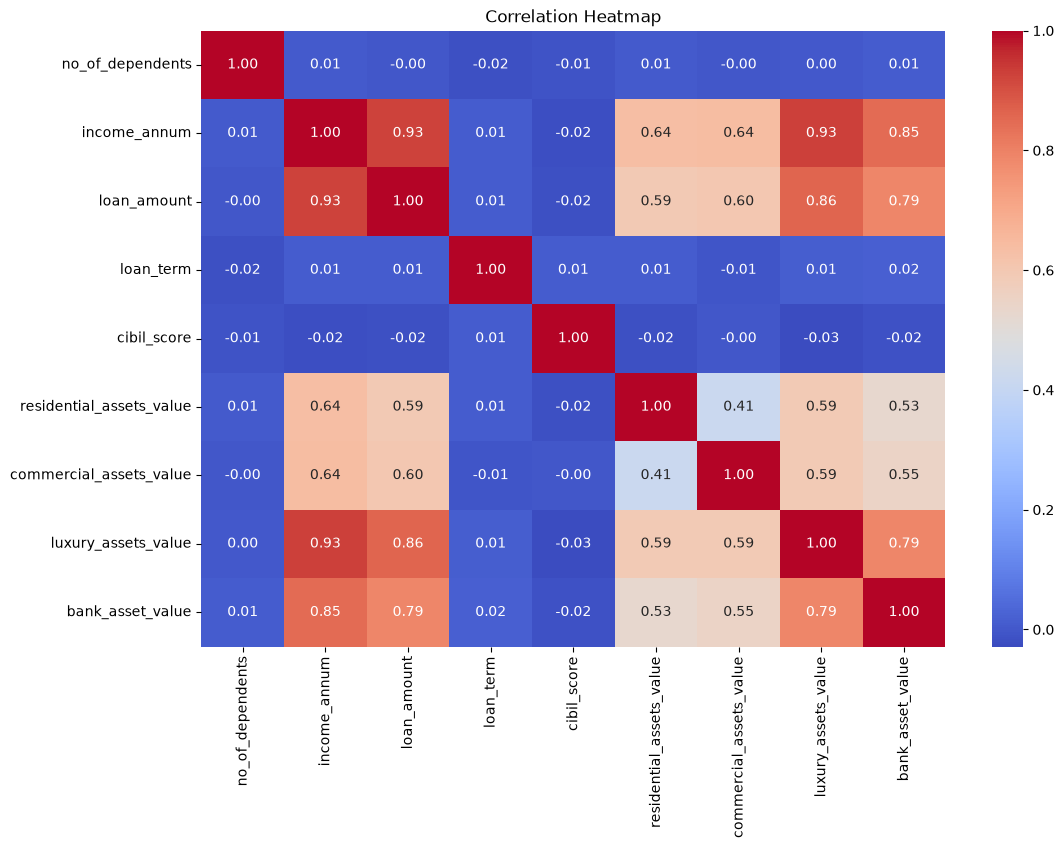

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [84]:
for col in categorical_cols:
    print(df[col].value_counts())
    print("-" * 50)

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64
--------------------------------------------------
self_employed
Yes    2150
No     2119
Name: count, dtype: int64
--------------------------------------------------
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64
--------------------------------------------------


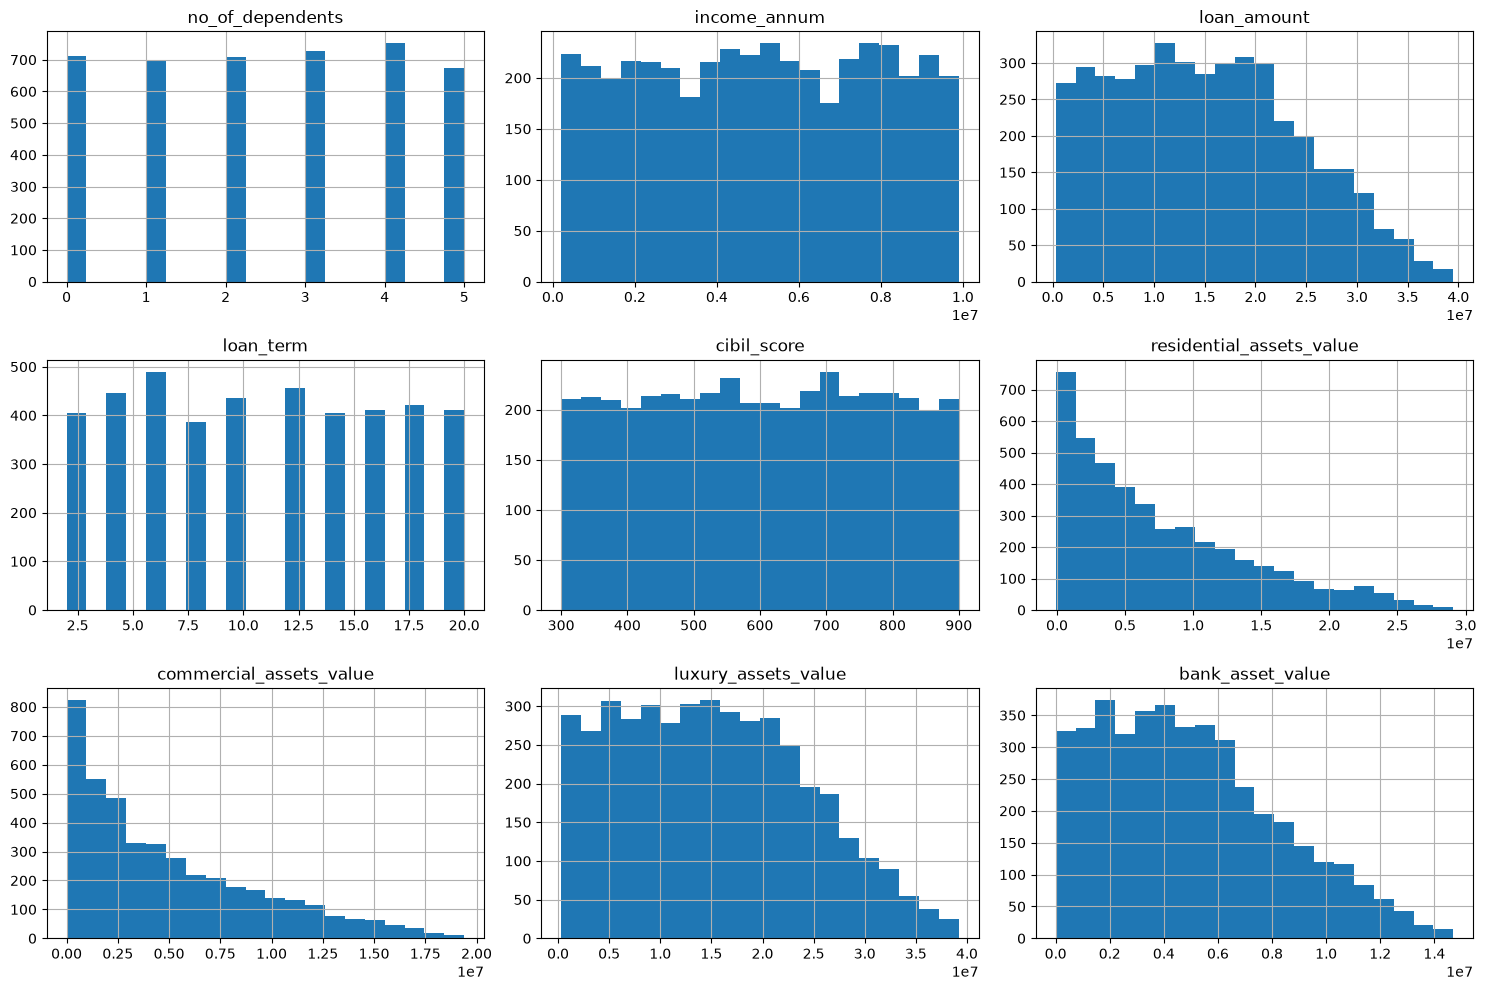

In [85]:
df[numerical_cols].hist(figsize=(15, 10), bins=20)

plt.tight_layout()
plt.show()

In [86]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [88]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print(X.shape)
print(y.shape)

(4269, 11)
(4269,)


In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [90]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3415, 11)
X_test shape: (854, 11)
y_train shape: (3415,)
y_test shape: (854,)


In [91]:
num_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

cat_features = X_train.select_dtypes(
    exclude=["number"]
).columns.tolist()

print(num_features)
print(cat_features)

['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
['education', 'self_employed']


In [92]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [93]:
num_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [94]:
cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [95]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_features),
        ("cat", cat_pipeline, cat_features)
    ]
)

In [96]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [97]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(3415, 13)
(854, 13)


In [98]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [99]:
print(le.classes_)

['Approved' 'Rejected']


In [100]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_processed, y_train_encoded)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [101]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_processed)

accuracy = accuracy_score(y_test_encoded, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9227


In [102]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       531
           1       0.92      0.88      0.90       323

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.92       854
weighted avg       0.92      0.92      0.92       854



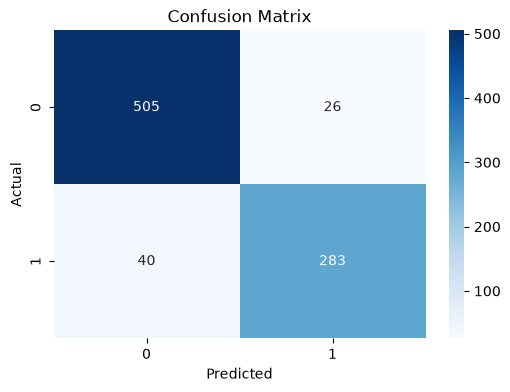

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [104]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [105]:
print(le.classes_)

['Approved' 'Rejected']


In [106]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

In [107]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier()
}

In [108]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score

In [109]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [110]:
results = {}

for name, model in models.items():

    model.fit(X_train_processed, y_train_encoded)

    y_pred = model.predict(X_test_processed)

    accuracy = accuracy_score(y_test_encoded, y_pred)
    f1 = f1_score(y_test_encoded, y_pred)

    results[name] = {
        "Accuracy": accuracy,
        "F1 Score": f1
    }

    print(f"{name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("-" * 30)

Logistic Regression
Accuracy: 0.9227
F1 Score: 0.8956
------------------------------
Decision Tree
Accuracy: 0.9731
F1 Score: 0.9641
------------------------------
Random Forest
Accuracy: 0.9813
F1 Score: 0.9748
------------------------------
XGBoost
Accuracy: 0.9824
F1 Score: 0.9765
------------------------------


In [111]:
best_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

best_model.fit(X_train_processed, y_train_encoded)

train_score = best_model.score(
    X_train_processed,
    y_train_encoded
)

test_score = best_model.score(
    X_test_processed,
    y_test_encoded
)

print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")

Train Accuracy: 1.0000
Test Accuracy: 0.9824


In [112]:
import joblib
import os

os.makedirs("artifacts", exist_ok=True)

joblib.dump(best_model, "artifacts/model.pkl")
joblib.dump(preprocessor, "artifacts/preprocessor.pkl")

['artifacts/preprocessor.pkl']

In [113]:
import os

os.listdir("artifacts")

['model.pkl', 'preprocessor.pkl']

In [114]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    best_model,
    X_train_processed,
    y_train_encoded,
    cv=5,
    scoring="f1"
)

print("CV Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))

CV Scores: [0.98046875 0.97455969 0.97109827 0.97286822 0.97674419]
Mean CV Score: 0.9751478211770366


In [115]:
best_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    max_depth=4,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8
)

In [116]:
import joblib
import os

os.makedirs("artifacts", exist_ok=True)

joblib.dump(best_model, "artifacts/model.pkl")
joblib.dump(preprocessor, "artifacts/preprocessor.pkl")

['artifacts/preprocessor.pkl']

In [117]:
import os
import joblib

os.makedirs("artifacts", exist_ok=True)

joblib.dump(best_model, "artifacts/model.pkl")
joblib.dump(preprocessor, "artifacts/preprocessor.pkl")

['artifacts/preprocessor.pkl']

In [118]:
os.listdir("artifacts")

['model.pkl', 'preprocessor.pkl']